# Heart Disease Prediction


## Install Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## Load Dataset

In [3]:
df: pd.DataFrame = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Dataset Overview

### Shape and Data Types

In [4]:
print("Shape:", df.shape)
df.info()

Shape: (1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### Statistical Summary

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


### Missing Values

In [6]:
missing: pd.Series = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found.")

No missing values found.


### Duplicate Rows

In [7]:
duplicate_count: int = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 723
Shape after removing duplicates: (302, 14)


## Exploratory Data Analysis

### Target Variable Distribution

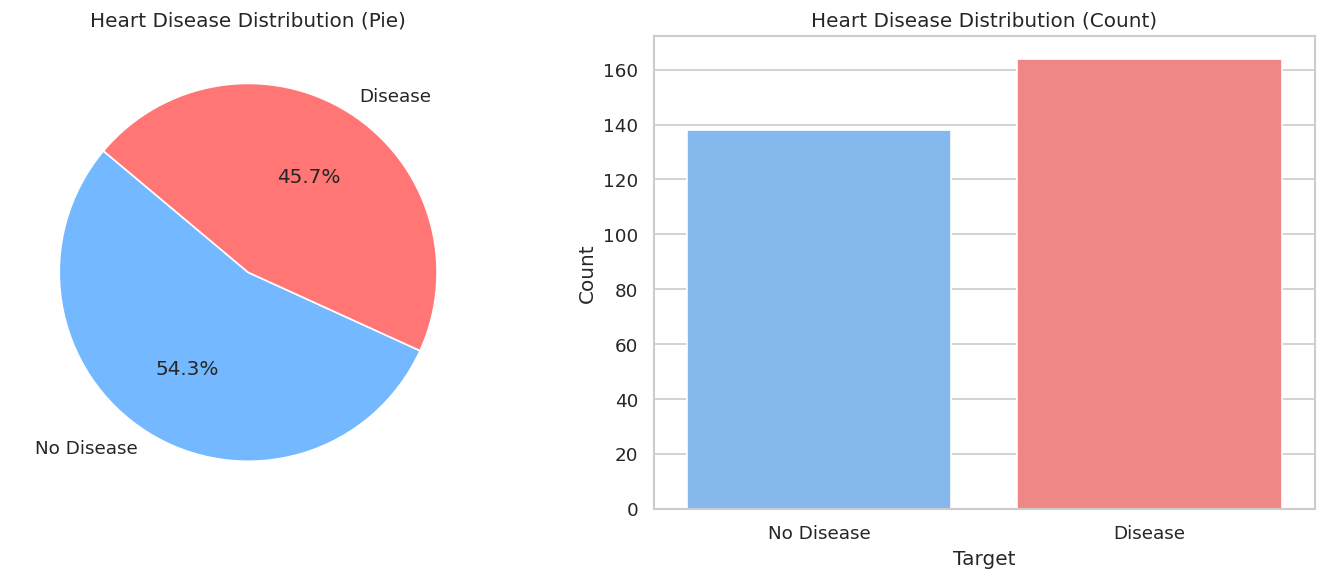

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts: pd.Series = df["target"].value_counts()
axes[0].pie(
    target_counts,
    labels=["No Disease", "Disease"],
    autopct="%1.1f%%",
    colors=["#74b9ff", "#ff7675"],
    startangle=140
)
axes[0].set_title("Heart Disease Distribution (Pie)")

sns.countplot(x="target", data=df, palette=["#74b9ff", "#ff7675"], ax=axes[1])
axes[1].set_title("Heart Disease Distribution (Count)")
axes[1].set_xticklabels(["No Disease", "Disease"])
axes[1].set_xlabel("Target")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Age Distribution

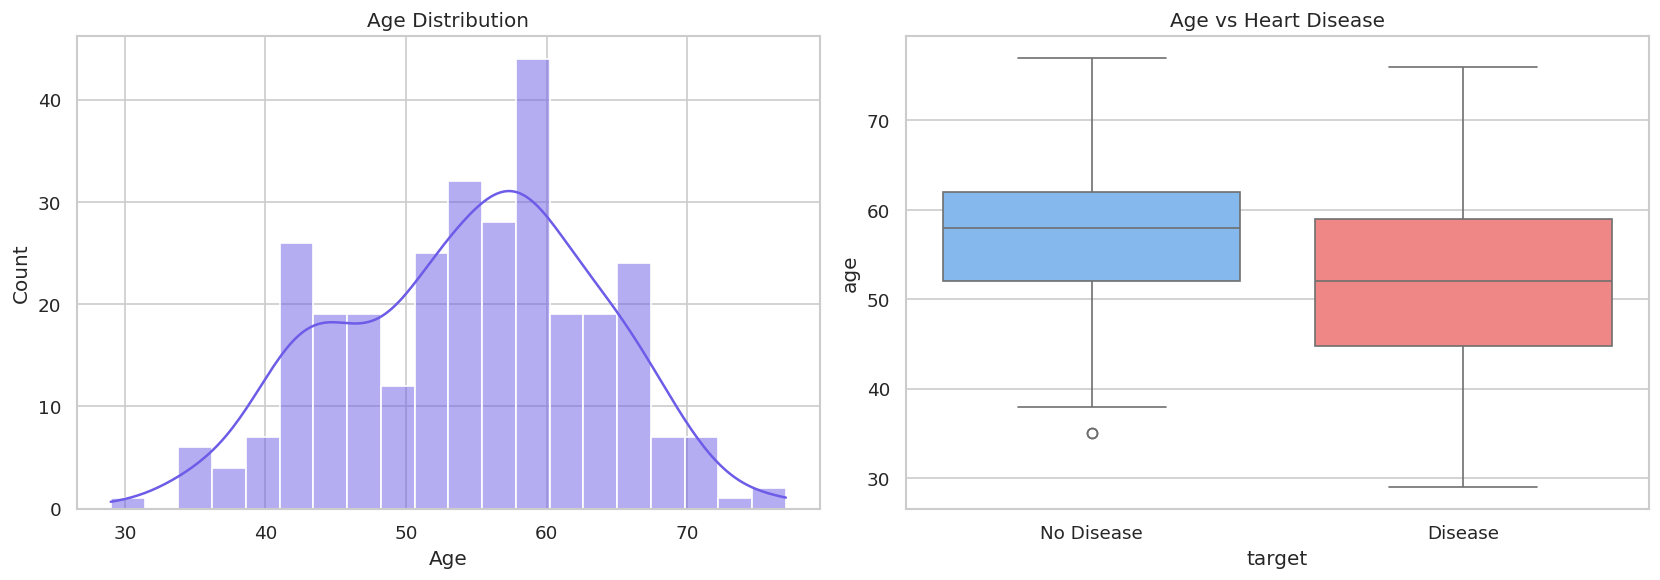

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["age"], bins=20, kde=True, color="#6c5ce7", ax=axes[0])
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

sns.boxplot(x="target", y="age", data=df, palette=["#74b9ff", "#ff7675"], ax=axes[1])
axes[1].set_title("Age vs Heart Disease")
axes[1].set_xticklabels(["No Disease", "Disease"])

plt.tight_layout()
plt.show()

### Gender Distribution and Heart Disease

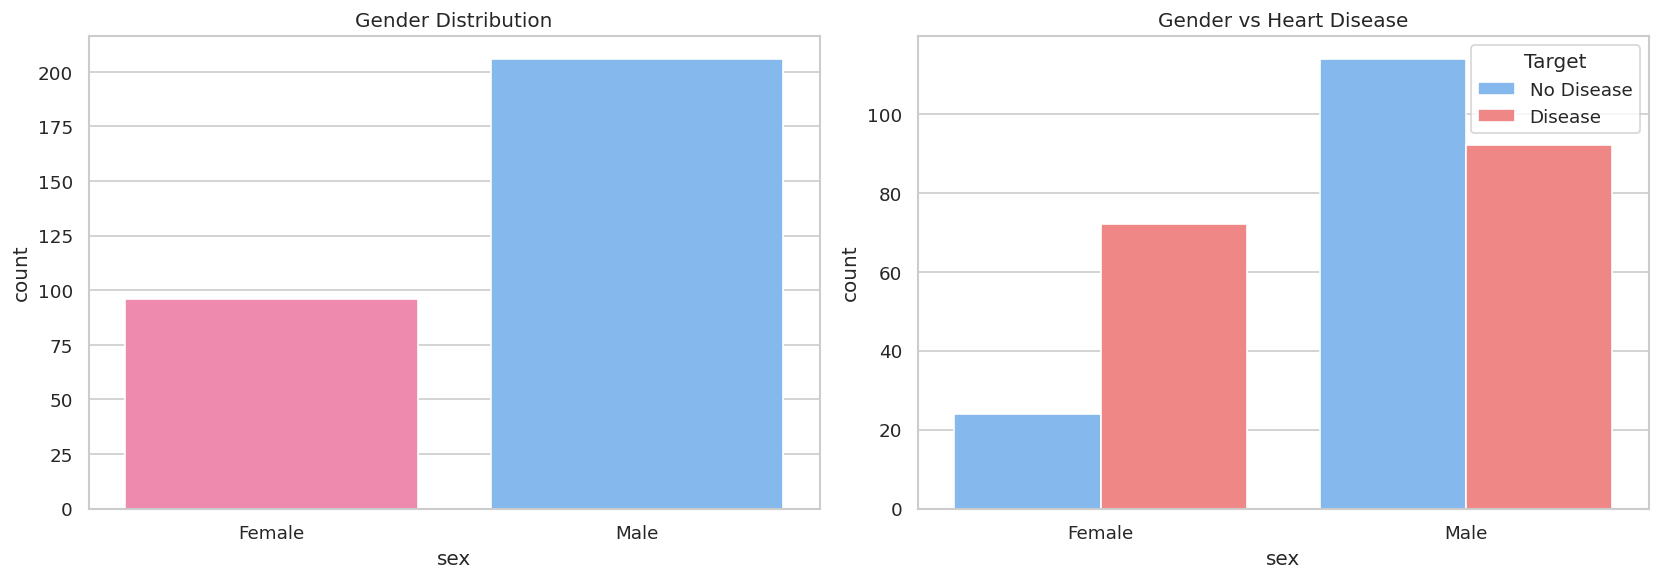

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x="sex", data=df, palette=["#fd79a8", "#74b9ff"], ax=axes[0])
axes[0].set_title("Gender Distribution")
axes[0].set_xticklabels(["Female", "Male"])

sns.countplot(x="sex", hue="target", data=df, palette=["#74b9ff", "#ff7675"], ax=axes[1])
axes[1].set_title("Gender vs Heart Disease")
axes[1].set_xticklabels(["Female", "Male"])
axes[1].legend(title="Target", labels=["No Disease", "Disease"])

plt.tight_layout()
plt.show()

### Chest Pain Type Analysis

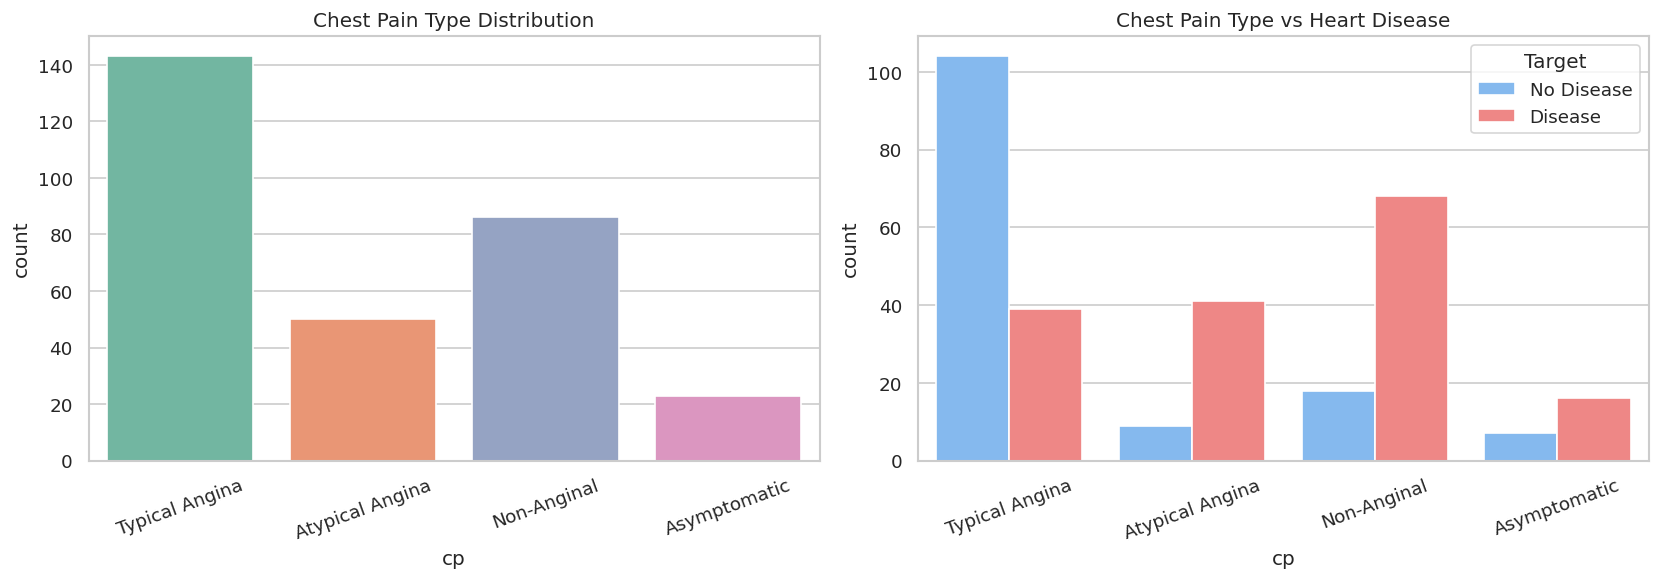

In [11]:
cp_labels: list[str] = ["Typical Angina", "Atypical Angina", "Non-Anginal", "Asymptomatic"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x="cp", data=df, palette="Set2", ax=axes[0])
axes[0].set_title("Chest Pain Type Distribution")
axes[0].set_xticklabels(cp_labels, rotation=20)

sns.countplot(x="cp", hue="target", data=df, palette=["#74b9ff", "#ff7675"], ax=axes[1])
axes[1].set_title("Chest Pain Type vs Heart Disease")
axes[1].set_xticklabels(cp_labels, rotation=20)
axes[1].legend(title="Target", labels=["No Disease", "Disease"])

plt.tight_layout()
plt.show()

### Continuous Features Distribution

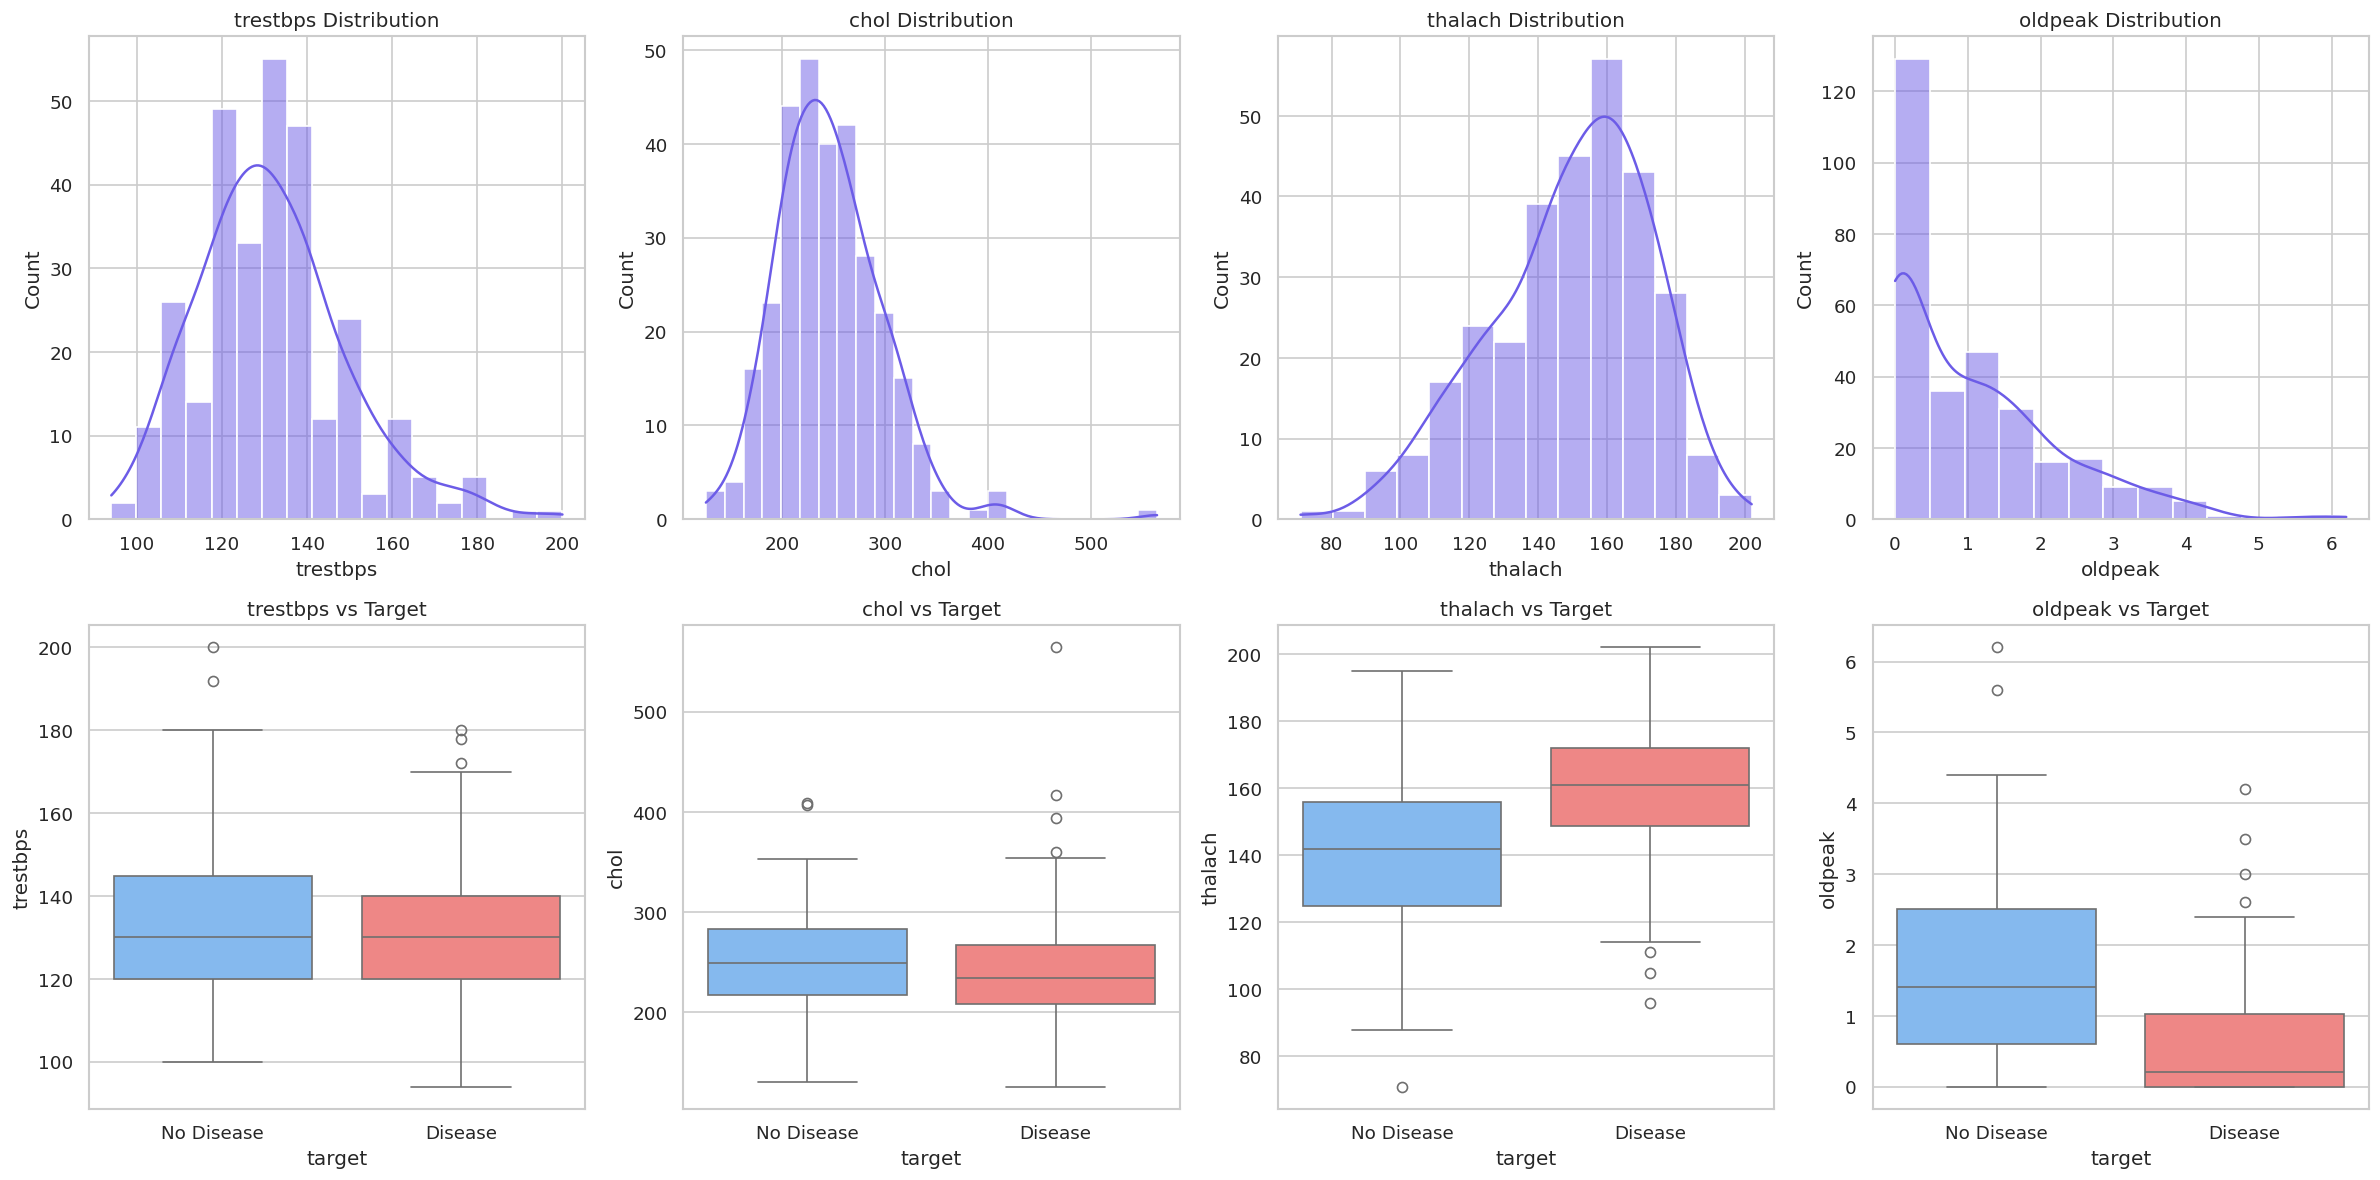

In [12]:
continuous_features: list[str] = ["trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for idx, feature in enumerate(continuous_features):
    sns.histplot(df[feature], kde=True, ax=axes[0, idx], color="#6c5ce7")
    axes[0, idx].set_title(f"{feature} Distribution")

    sns.boxplot(x="target", y=feature, data=df, palette=["#74b9ff", "#ff7675"], ax=axes[1, idx])
    axes[1, idx].set_title(f"{feature} vs Target")
    axes[1, idx].set_xticklabels(["No Disease", "Disease"])

plt.tight_layout()
plt.show()

### Categorical Features vs Target

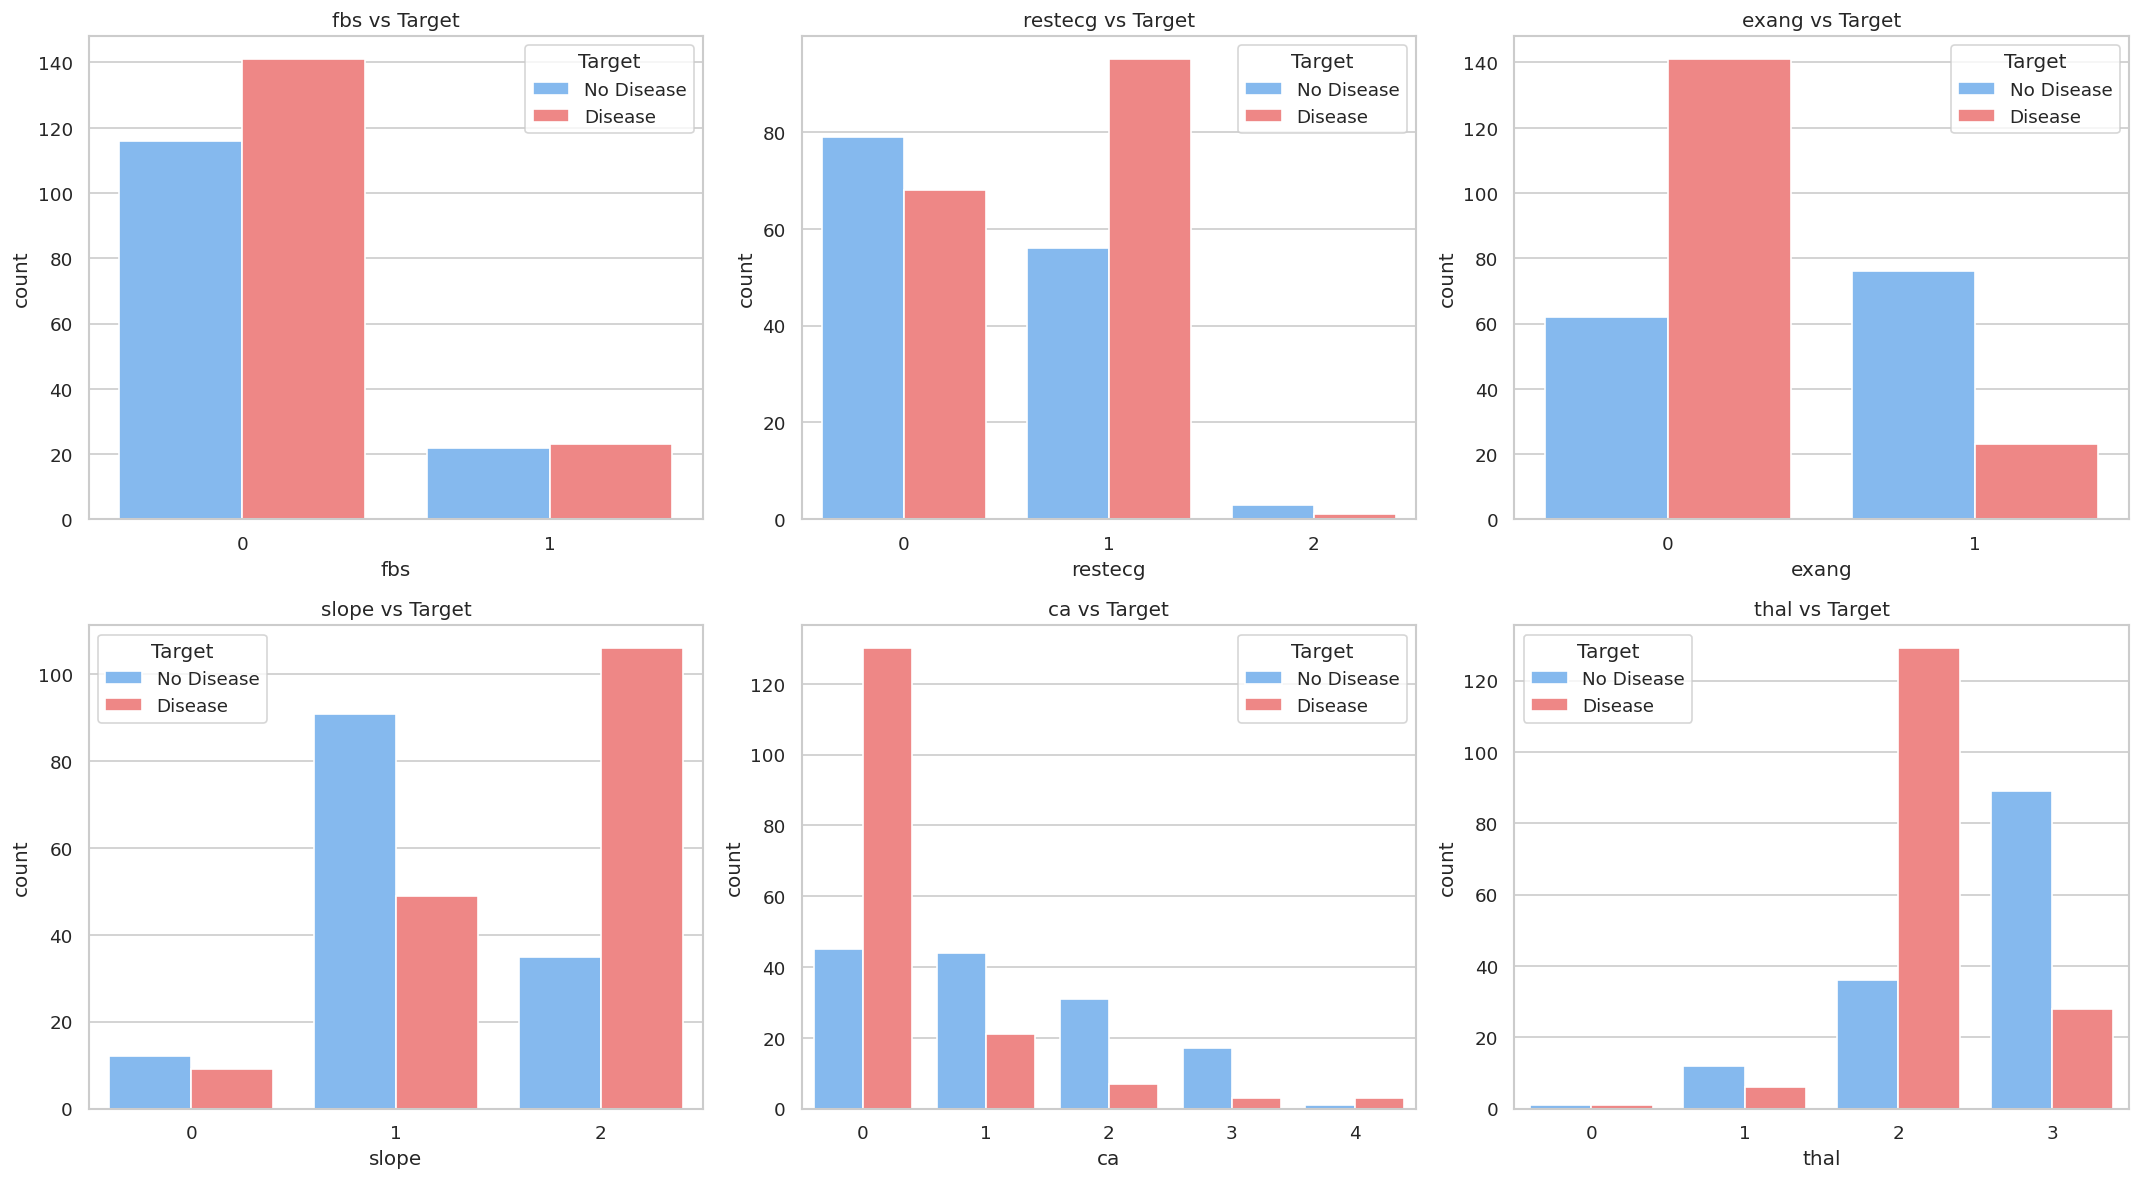

In [13]:
categorical_features: list[str] = ["fbs", "restecg", "exang", "slope", "ca", "thal"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    sns.countplot(x=feature, hue="target", data=df, palette=["#74b9ff", "#ff7675"], ax=axes[idx])
    axes[idx].set_title(f"{feature} vs Target")
    axes[idx].legend(title="Target", labels=["No Disease", "Disease"])

plt.tight_layout()
plt.show()

### Correlation Heatmap

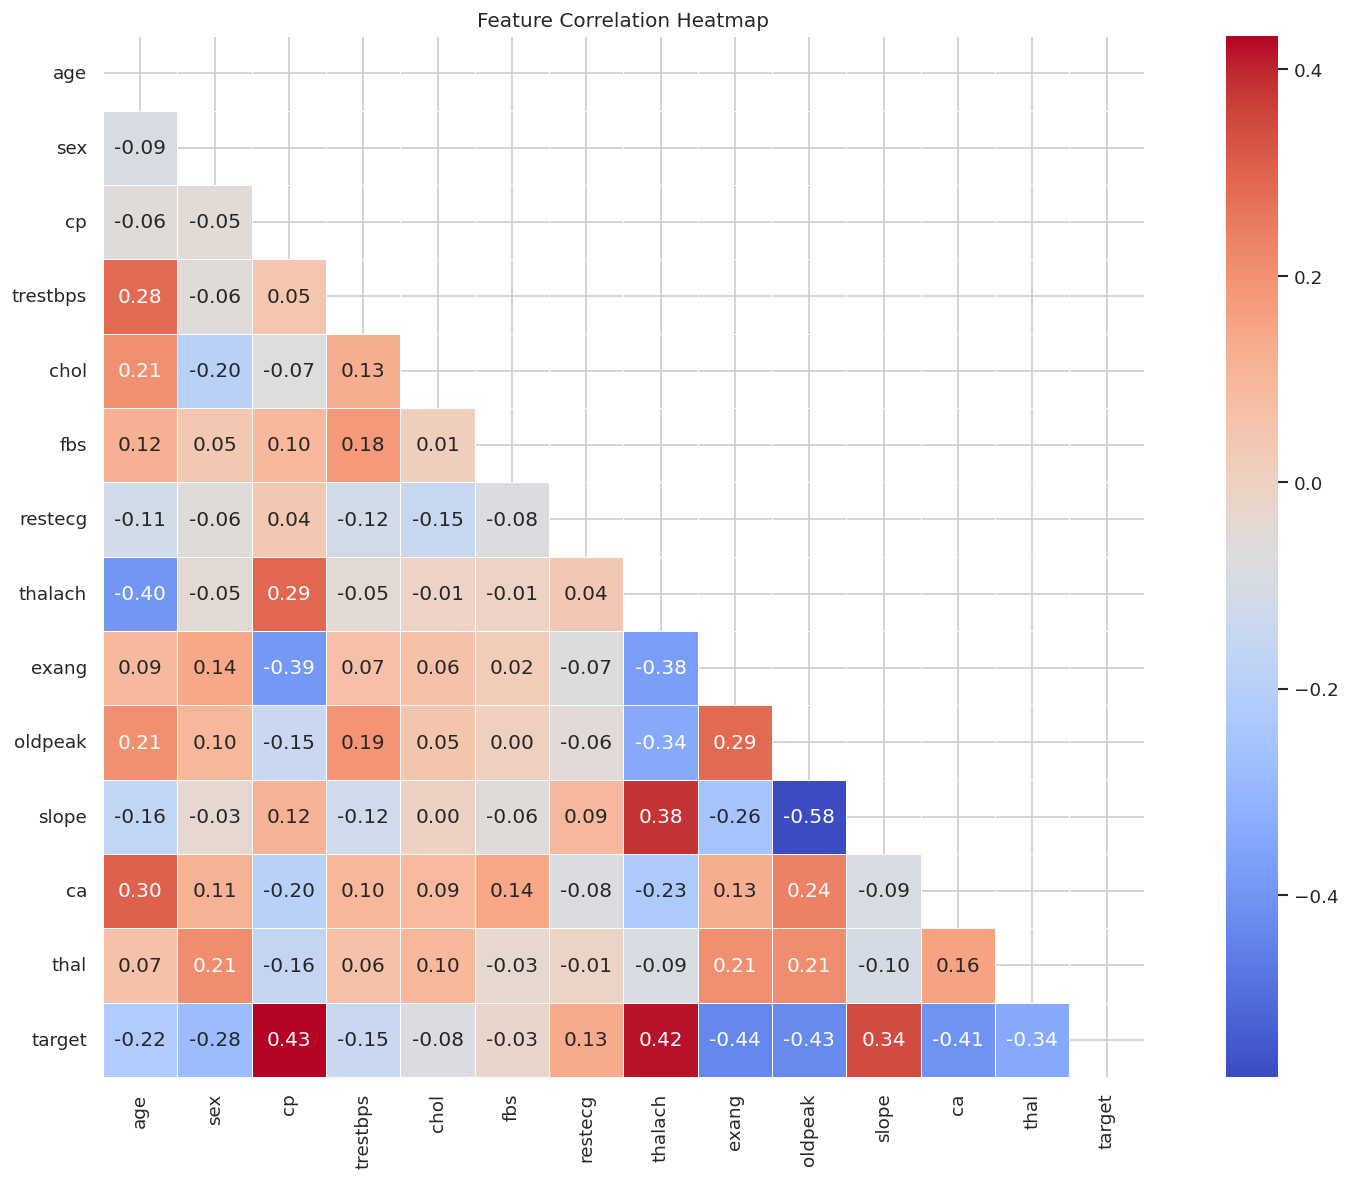

In [14]:
plt.figure(figsize=(14, 10))
correlation_matrix: pd.DataFrame = df.corr(numeric_only=True)
mask: np.ndarray = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Feature Correlation with Target

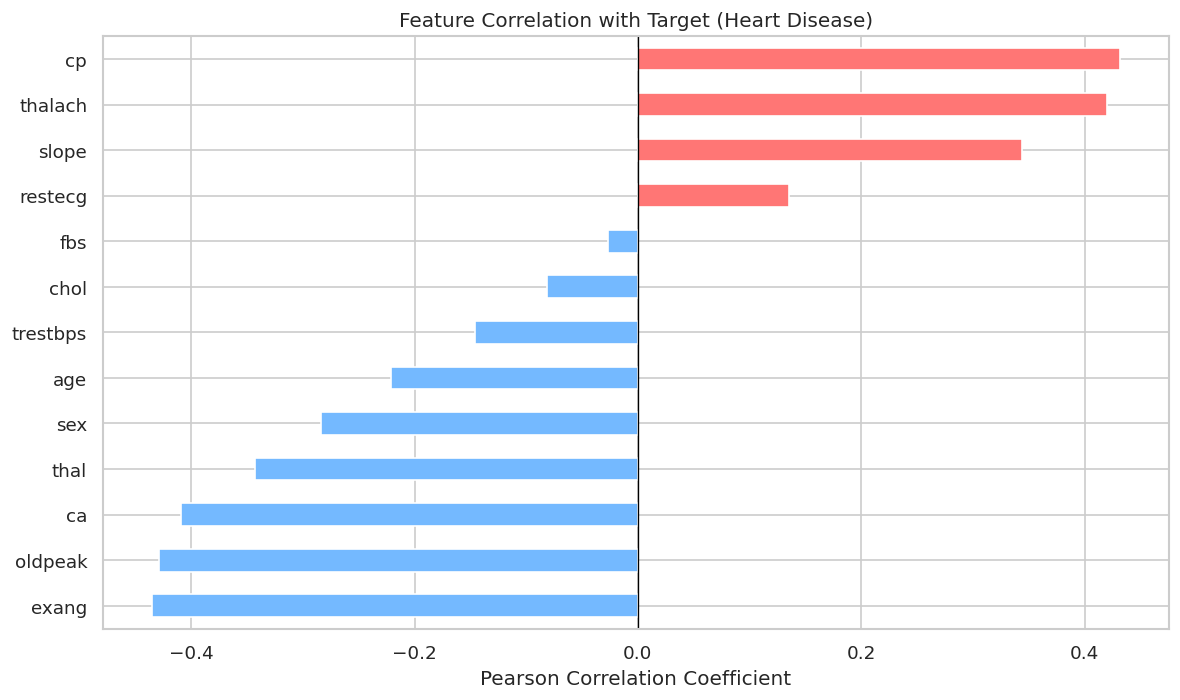

In [15]:
target_corr: pd.Series = correlation_matrix["target"].drop("target").sort_values()
colors: list[str] = ["#ff7675" if val > 0 else "#74b9ff" for val in target_corr]

plt.figure(figsize=(10, 6))
target_corr.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Target (Heart Disease)")
plt.xlabel("Pearson Correlation Coefficient")
plt.tight_layout()
plt.show()

### Pairplot of Key Features

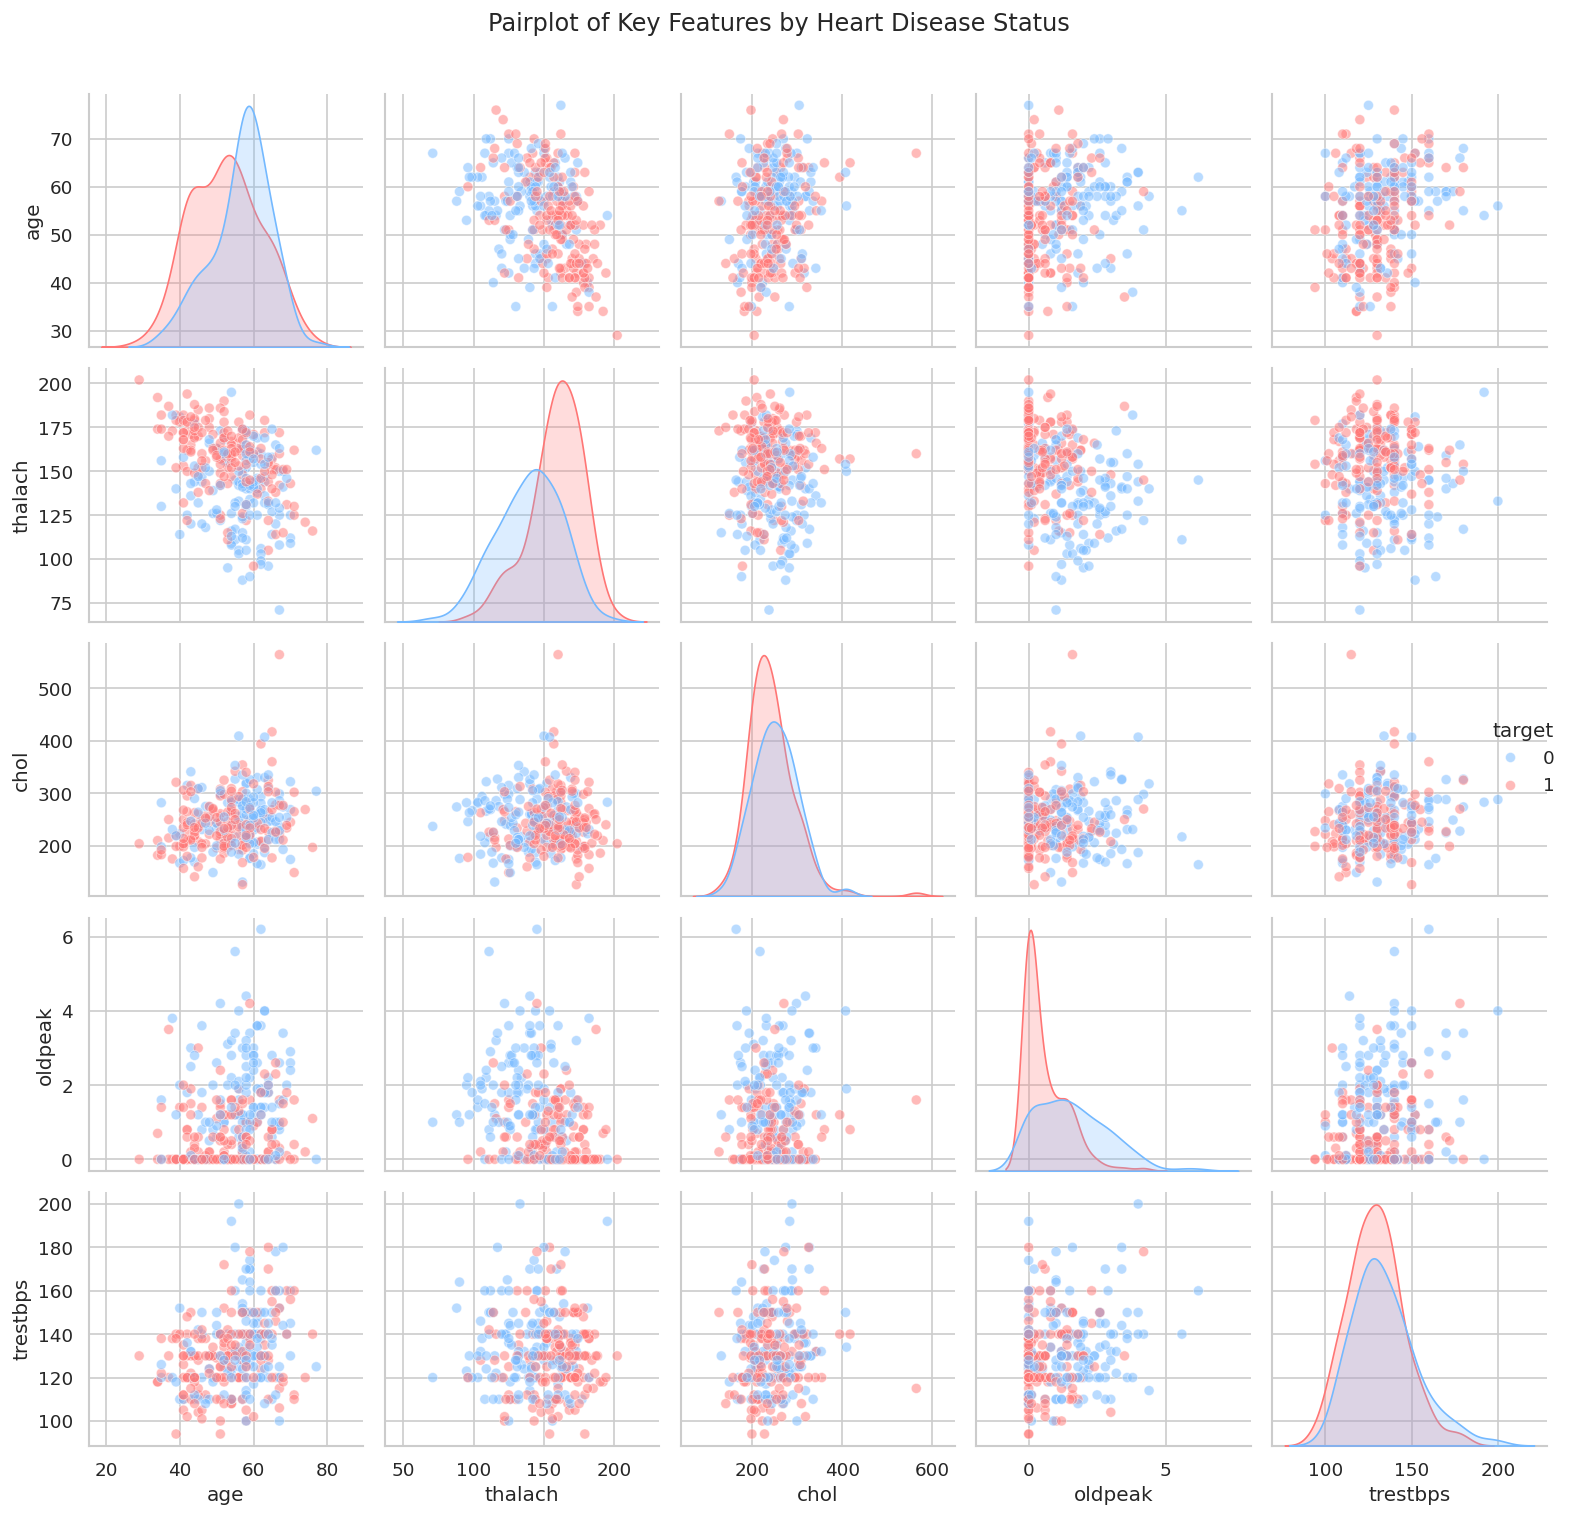

In [16]:
key_features: list[str] = ["age", "thalach", "chol", "oldpeak", "trestbps", "target"]
pair_df: pd.DataFrame = df[key_features].copy()

sns.pairplot(pair_df, hue="target", palette=["#74b9ff", "#ff7675"], diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot of Key Features by Heart Disease Status", y=1.01)
plt.tight_layout()
plt.show()

### Violin Plots — Key Continuous Features

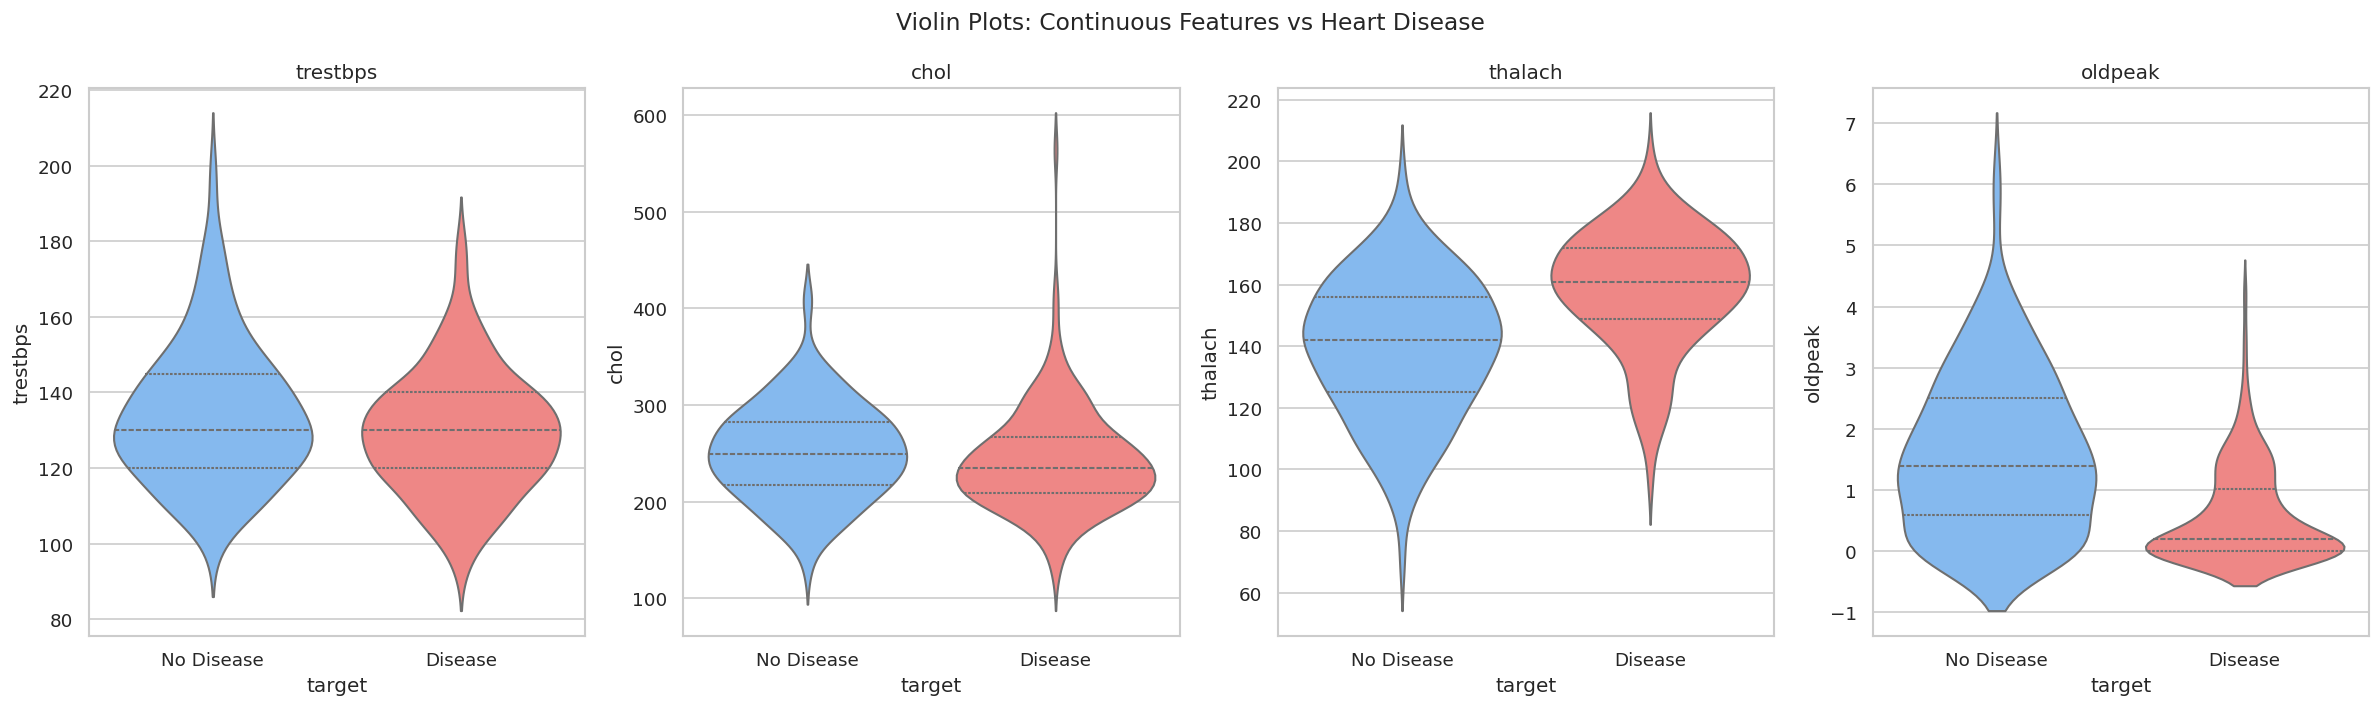

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for idx, feature in enumerate(continuous_features):
    sns.violinplot(x="target", y=feature, data=df, palette=["#74b9ff", "#ff7675"], inner="quartile", ax=axes[idx])
    axes[idx].set_title(f"{feature}")
    axes[idx].set_xticklabels(["No Disease", "Disease"])

plt.suptitle("Violin Plots: Continuous Features vs Heart Disease", fontsize=14)
plt.tight_layout()
plt.show()

### Outlier Detection — IQR Method

In [18]:
def count_outliers(series: pd.Series) -> int:
    q1: float = series.quantile(0.25)
    q3: float = series.quantile(0.75)
    iqr: float = q3 - q1
    lower_bound: float = q1 - 1.5 * iqr
    upper_bound: float = q3 + 1.5 * iqr
    return int(((series < lower_bound) | (series > upper_bound)).sum())

outlier_summary: pd.DataFrame = pd.DataFrame({
    "Feature": continuous_features,
    "Outlier Count": [count_outliers(df[f]) for f in continuous_features]
})
print(outlier_summary.to_string(index=False))

 Feature  Outlier Count
trestbps              9
    chol              5
 thalach              1
 oldpeak              5


### Age Group Analysis

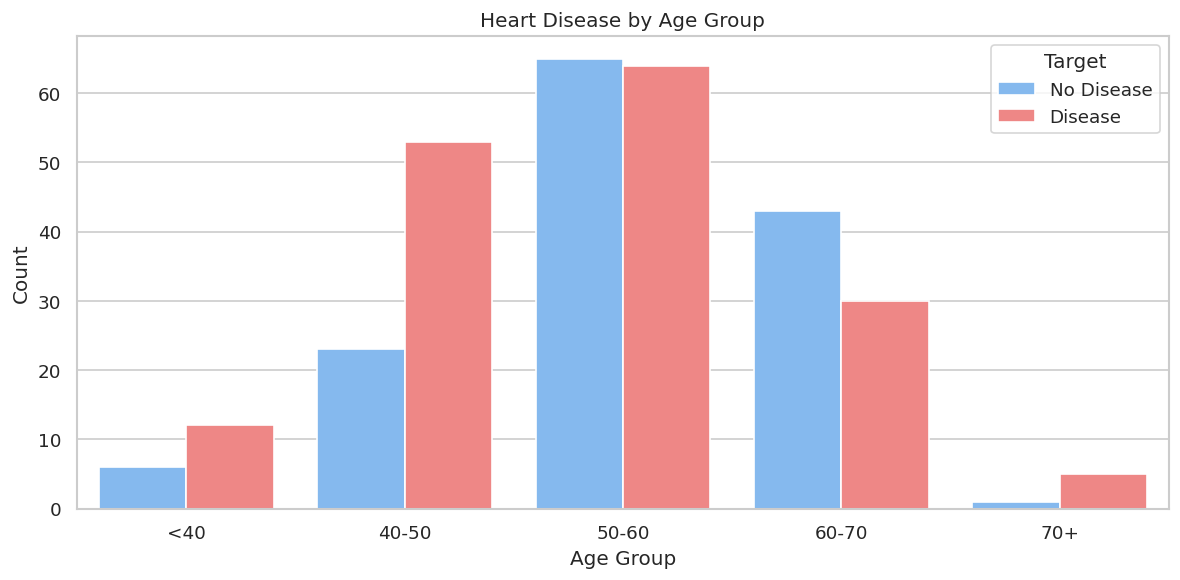

In [19]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 50, 60, 70, 100],
    labels=["<40", "40-50", "50-60", "60-70", "70+"]
)

plt.figure(figsize=(10, 5))
sns.countplot(x="age_group", hue="target", data=df, palette=["#74b9ff", "#ff7675"])
plt.title("Heart Disease by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Target", labels=["No Disease", "Disease"])
plt.tight_layout()
plt.show()

df.drop(columns=["age_group"], inplace=True)

### EDA Summary

In [20]:
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")

disease_pct: float = df["target"].mean() * 100
print(f"\n1. Target Balance     : {disease_pct:.1f}% with heart disease, {100 - disease_pct:.1f}% without.")

top_pos: str = target_corr[target_corr > 0].index[-1]
top_neg: str = target_corr[target_corr < 0].index[0]
print(f"\n2. Strongest Positive Correlation with target : '{top_pos}' ({target_corr[top_pos]:.2f})")
print(f"   Strongest Negative Correlation with target : '{top_neg}' ({target_corr[top_neg]:.2f})")

print(f"\n3. Age Range          : {df['age'].min()} - {df['age'].max()} years (mean: {df['age'].mean():.1f})")
print(f"\n4. Male patients      : {(df['sex'] == 1).sum()} | Female patients: {(df['sex'] == 0).sum()}")
print(f"\n5. Cholesterol Range  : {df['chol'].min()} - {df['chol'].max()} mg/dl")
print(f"\n6. Dataset Shape      : {df.shape[0]} rows x {df.shape[1]} columns (after dedup)")

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. Target Balance     : 54.3% with heart disease, 45.7% without.

2. Strongest Positive Correlation with target : 'cp' (0.43)
   Strongest Negative Correlation with target : 'exang' (-0.44)

3. Age Range          : 29 - 77 years (mean: 54.4)

4. Male patients      : 206 | Female patients: 96

5. Cholesterol Range  : 126 - 564 mg/dl

6. Dataset Shape      : 302 rows x 14 columns (after dedup)


## Data Preprocessing

### Separate Features and Target

In [21]:
X: pd.DataFrame = df.drop(columns=["target"])
y: pd.Series = df["target"]

print("Feature matrix shape :", X.shape)
print("Target vector shape  :", y.shape)
print("Class distribution   :\n", y.value_counts())

Feature matrix shape : (302, 13)
Target vector shape  : (302,)
Class distribution   :
 target
1    164
0    138
Name: count, dtype: int64


### Train-Test Split

In [22]:
X_train: pd.DataFrame
X_test: pd.DataFrame
y_train: pd.Series
y_test: pd.Series

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")

Training set   : 241 samples
Test set       : 61 samples


### Handle Class Imbalance with SMOTE

Before SMOTE — Class distribution:
target
1    131
0    110

After SMOTE  — Class distribution:
target
1    131
0    131


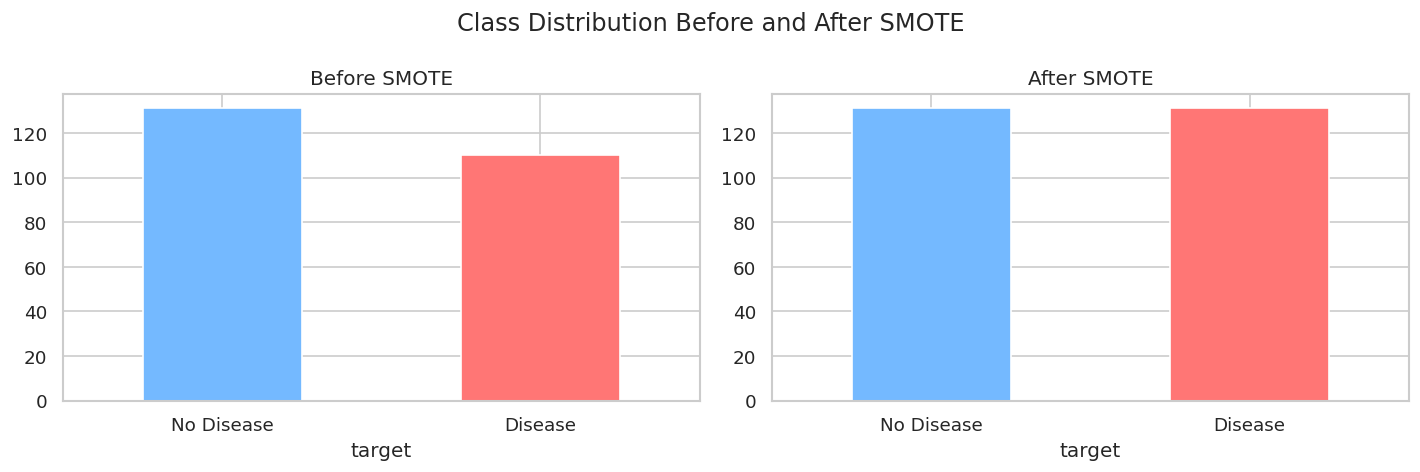

In [23]:
smote: SMOTE = SMOTE(random_state=42)
X_train_resampled: np.ndarray
y_train_resampled: np.ndarray

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE — Class distribution:")
print(pd.Series(y_train).value_counts().to_string())
print("\nAfter SMOTE  — Class distribution:")
print(pd.Series(y_train_resampled).value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).value_counts().plot(kind="bar", ax=axes[0], color=["#74b9ff", "#ff7675"])
axes[0].set_title("Before SMOTE")
axes[0].set_xticklabels(["No Disease", "Disease"], rotation=0)

pd.Series(y_train_resampled).value_counts().plot(kind="bar", ax=axes[1], color=["#74b9ff", "#ff7675"])
axes[1].set_title("After SMOTE")
axes[1].set_xticklabels(["No Disease", "Disease"], rotation=0)

plt.suptitle("Class Distribution Before and After SMOTE")
plt.tight_layout()
plt.show()

## Model Training

### Define Classifiers

In [24]:
from sklearn.pipeline import Pipeline

classifiers: dict[str, Pipeline] = {
    "Random Forest": make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42)),
    "Gradient Boosting": make_pipeline(StandardScaler(), GradientBoostingClassifier(random_state=42)),
    "SVM": make_pipeline(StandardScaler(), SVC(probability=True, random_state=42)),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier())
}

print("Classifiers defined:")
for name in classifiers:
    print(f"  - {name}")

Classifiers defined:
  - Random Forest
  - Gradient Boosting
  - SVM
  - Logistic Regression
  - KNN


### Cross-Validation and Evaluation

In [25]:
cv: StratifiedKFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results: list[dict] = []
best_accuracy: float = 0.0
best_clf_name: str = ""
best_clf: Pipeline = None

for name, pipeline in classifiers.items():
    scores: np.ndarray = cross_val_score(
        pipeline, X_train_resampled, y_train_resampled, cv=cv, scoring="accuracy"
    )
    mean_acc: float = scores.mean()
    std_acc: float = scores.std()

    pipeline.fit(X_train_resampled, y_train_resampled)
    y_pred: np.ndarray = pipeline.predict(X_test)
    test_acc: float = accuracy_score(y_test, y_pred)
    roc_auc: float = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])

    results.append({
        "Model": name,
        "CV Mean Accuracy": round(mean_acc, 4),
        "CV Std": round(std_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "ROC-AUC": round(roc_auc, 4)
    })

    print(f"Model            : {name}")
    print(f"CV Accuracy      : {mean_acc:.4f} (+/- {std_acc:.4f})")
    print(f"Test Accuracy    : {test_acc:.4f}")
    print(f"ROC-AUC          : {roc_auc:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['No Disease', 'Disease'])}")

    if mean_acc > best_accuracy:
        best_accuracy = mean_acc
        best_clf_name = name
        best_clf = pipeline

print(f"Best Classifier  : {best_clf_name}")
print(f"Best CV Accuracy : {best_accuracy:.4f}")


Model            : Random Forest
CV Accuracy      : 0.8434 (+/- 0.0352)
Test Accuracy    : 0.7705
ROC-AUC          : 0.8826

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.75      0.75      0.75        28
     Disease       0.79      0.79      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61


Model            : Gradient Boosting
CV Accuracy      : 0.8322 (+/- 0.0241)
Test Accuracy    : 0.7213
ROC-AUC          : 0.8193

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.68      0.75      0.71        28
     Disease       0.77      0.70      0.73        33

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.73      0.72      0.72        61


Model            : SVM
CV Accuracy      : 0

## Model Comparison

### Results Table

In [26]:
results_df: pd.DataFrame = pd.DataFrame(results).sort_values("CV Mean Accuracy", ascending=False)
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,CV Mean Accuracy,CV Std,Test Accuracy,ROC-AUC
0,KNN,0.8553,0.0566,0.7869,0.8393
1,Logistic Regression,0.8509,0.0336,0.8197,0.8810
2,SVM,0.8475,0.0199,0.7541,0.8431
3,Random Forest,0.8434,0.0352,0.7705,0.8826
4,Gradient Boosting,0.8322,0.0241,0.7213,0.8193


### Accuracy Comparison Bar Chart

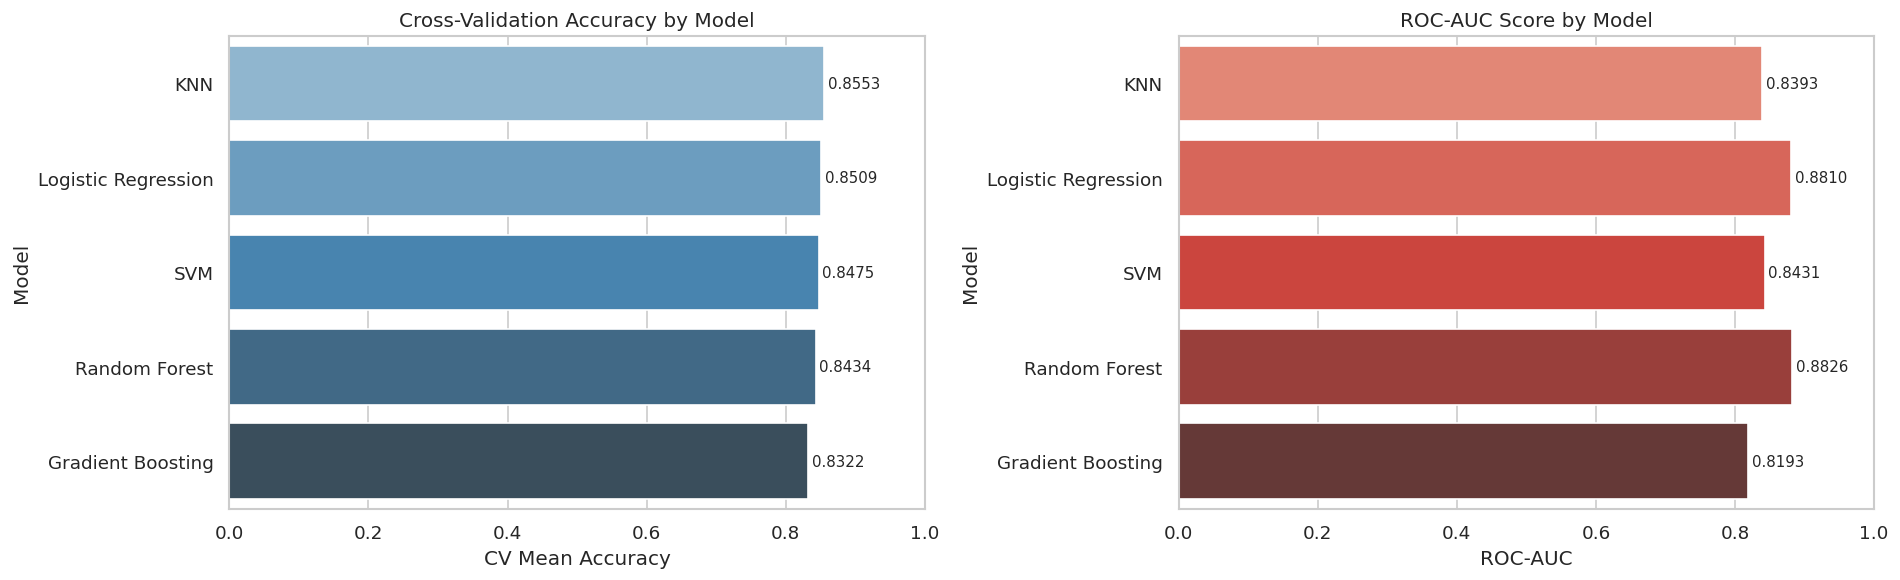

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    x="CV Mean Accuracy", y="Model", data=results_df,
    palette="Blues_d", ax=axes[0]
)
axes[0].set_title("Cross-Validation Accuracy by Model")
axes[0].set_xlim(0, 1)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.4f}",
        va="center", fontsize=9
    )

sns.barplot(
    x="ROC-AUC", y="Model", data=results_df,
    palette="Reds_d", ax=axes[1]
)
axes[1].set_title("ROC-AUC Score by Model")
axes[1].set_xlim(0, 1)
for bar in axes[1].patches:
    axes[1].text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.4f}",
        va="center", fontsize=9
    )

plt.tight_layout()
plt.show()

### Confusion Matrices — All Models

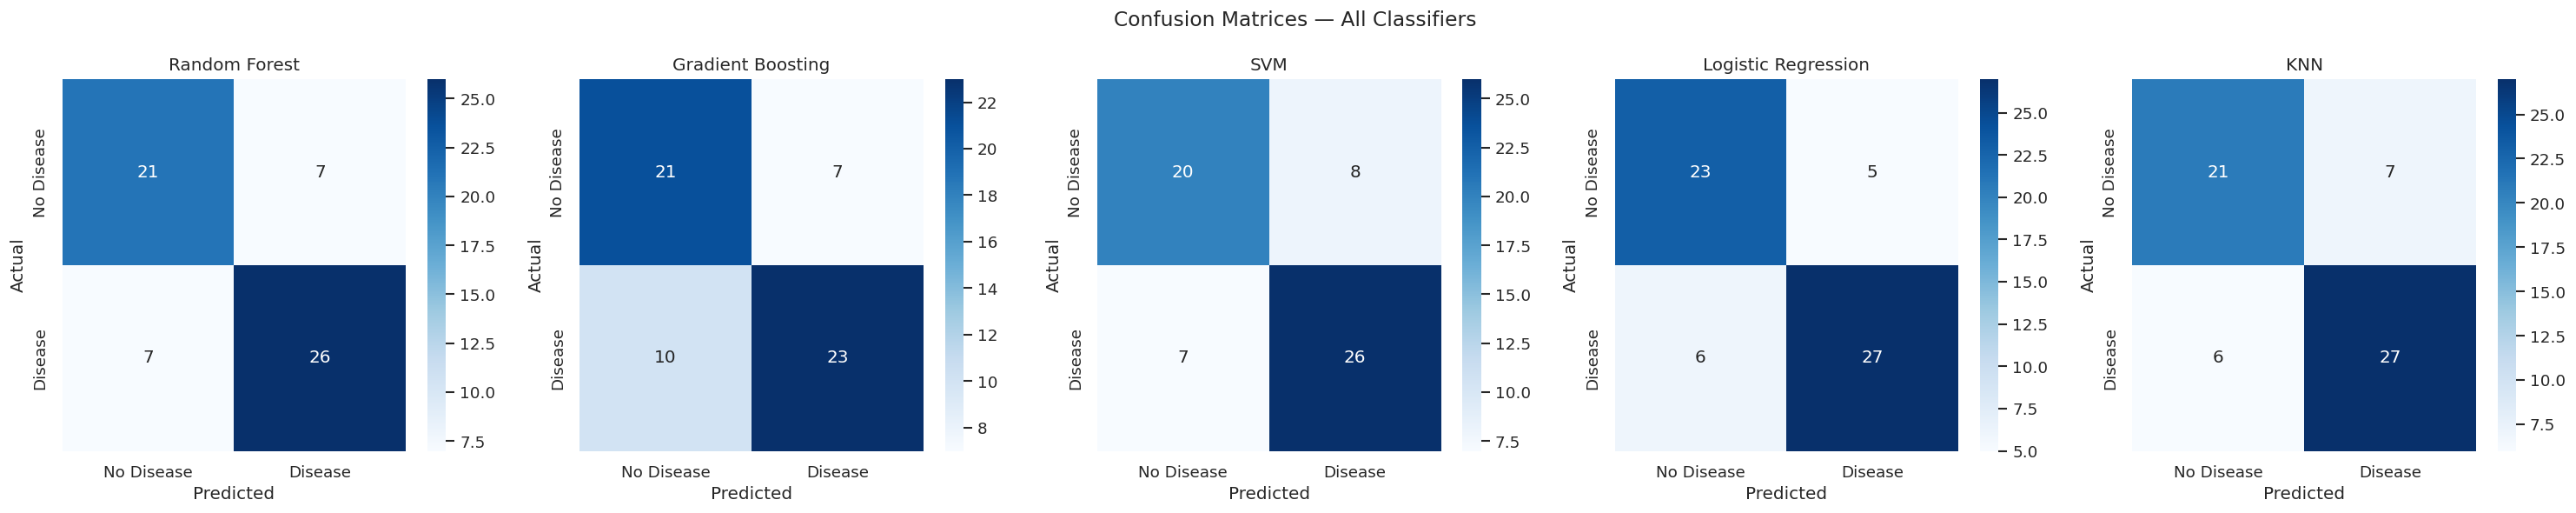

In [28]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for idx, (name, pipeline) in enumerate(classifiers.items()):
    y_pred_cm: np.ndarray = pipeline.predict(X_test)
    cm: np.ndarray = confusion_matrix(y_test, y_pred_cm)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["No Disease", "Disease"],
        yticklabels=["No Disease", "Disease"],
        ax=axes[idx]
    )
    axes[idx].set_title(name)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Classifiers", fontsize=14)
plt.tight_layout()
plt.show()

### ROC Curves — All Models

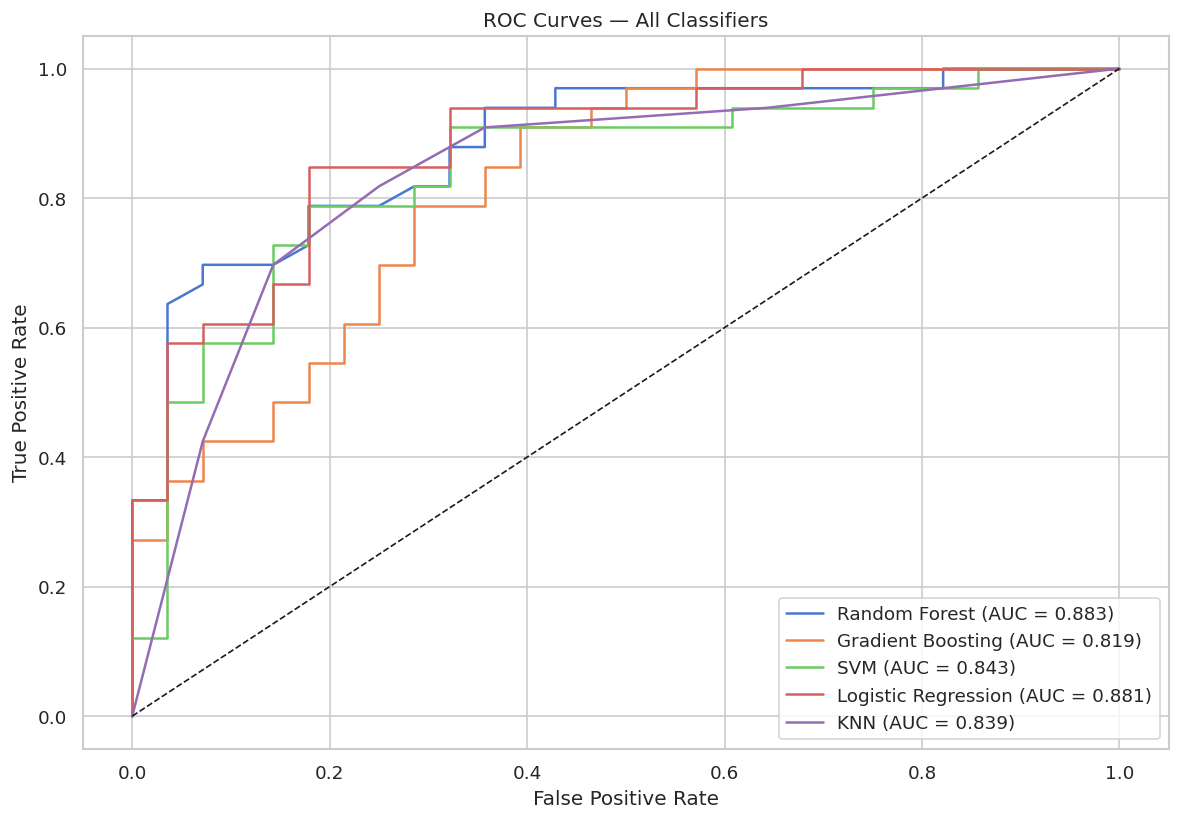

In [29]:
plt.figure(figsize=(10, 7))

for name, pipeline in classifiers.items():
    y_prob: np.ndarray = pipeline.predict_proba(X_test)[:, 1]
    fpr: np.ndarray
    tpr: np.ndarray
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score: float = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Classifiers")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Feature Importance — Random Forest

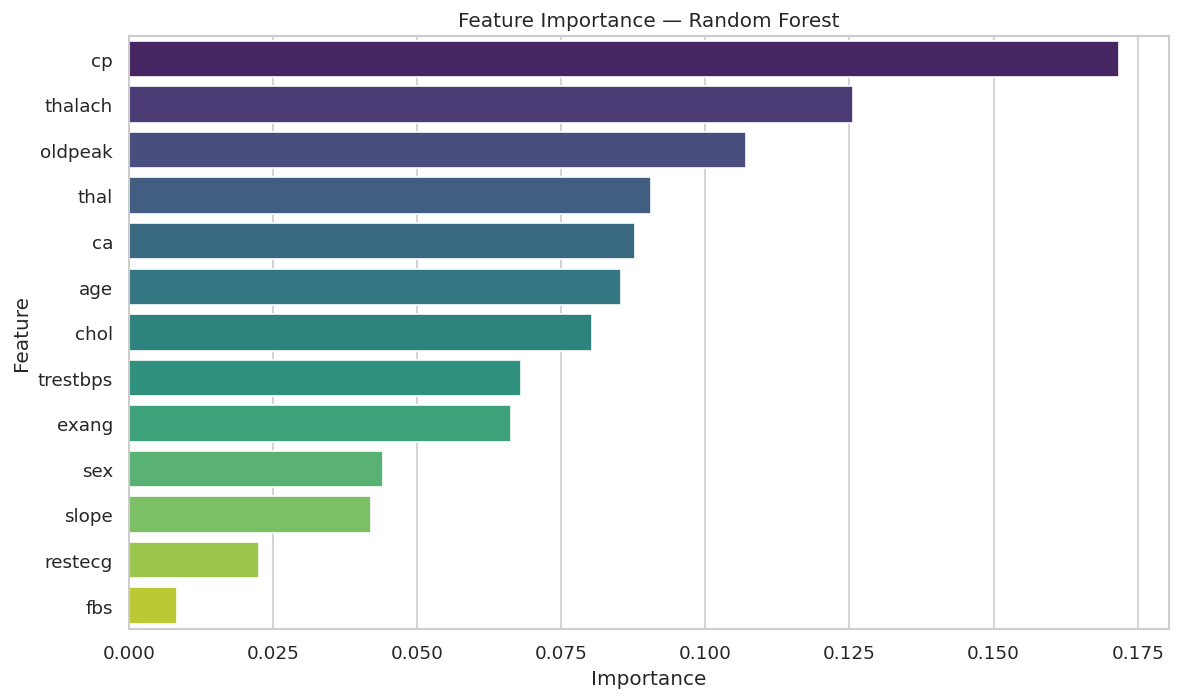

,Feature,Importance
2,cp,0.171798
7,thalach,0.125560
9,oldpeak,0.107108
12,thal,0.090547
11,ca,0.087809
0,age,0.085315
4,chol,0.080342
3,trestbps,0.068033
8,exang,0.066336
1,sex,0.044079


In [30]:
rf_pipeline: Pipeline = classifiers["Random Forest"]
rf_model: RandomForestClassifier = rf_pipeline.named_steps["randomforestclassifier"]

feature_importance_df: pd.DataFrame = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

feature_importance_df

## Save Best Model

### Save as Pickle File

In [31]:
model_path: str = "best_classifier.pkl"

with open(model_path, "wb") as f:
    pickle.dump(best_clf, f)

print(f"Best model saved : '{model_path}'")
print(f"Model name       : {best_clf_name}")
print(f"CV Accuracy      : {best_accuracy:.4f}")

Best model saved : 'best_classifier.pkl'
Model name       : KNN
CV Accuracy      : 0.8553


### Verify Saved Model

In [32]:
with open(model_path, "rb") as f:
    loaded_model: Pipeline = pickle.load(f)

print("Model loaded successfully!")

sample_data: np.ndarray = X_test.iloc[0].values.reshape(1, -1)
prediction: np.ndarray = loaded_model.predict(sample_data)
prediction_proba: np.ndarray = loaded_model.predict_proba(sample_data)

print(f"\nSample patient features : {sample_data}")
print(f"Actual label            : {y_test.iloc[0]}")
print(f"Predicted label         : {prediction[0]}")
print(f"Prediction probability  : No Disease={prediction_proba[0][0]:.4f}, Disease={prediction_proba[0][1]:.4f}")

if prediction[0] == 1:
    print("\nResult: The model predicts the patient HAS heart disease.")
else:
    print("\nResult: The model predicts the patient does NOT have heart disease.")

Model loaded successfully!

Sample patient features : [[ 61.   0.   0. 145. 307.   0.   0. 146.   1.   1.   1.   0.   3.]]
Actual label            : 0
Predicted label         : 0
Prediction probability  : No Disease=0.8000, Disease=0.2000

Result: The model predicts the patient does NOT have heart disease.


## Hyperparameter Tuning

### Grid Search on Best Model

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid: dict = {
    "kneighborsclassifier__n_neighbors": [3, 5, 7, 9, 11],
    "kneighborsclassifier__weights": ["uniform", "distance"],
    "kneighborsclassifier__metric": ["euclidean", "manhattan"]
}

grid_search: GridSearchCV = GridSearchCV(
    best_clf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)

print("Best Parameters  :", grid_search.best_params_)
print("Best CV Accuracy :", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters  : {'kneighborsclassifier__metric': 'manhattan', 'kneighborsclassifier__n_neighbors': 11, 'kneighborsclassifier__weights': 'distance'}
Best CV Accuracy : 0.8361


### Evaluate Tuned Model

In [35]:
tuned_model: Pipeline = grid_search.best_estimator_
y_pred_tuned: np.ndarray = tuned_model.predict(X_test)

print("Tuned Model Test Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned, target_names=["No Disease", "Disease"]))

Tuned Model Test Accuracy : 0.8032786885245902

Classification Report:
               precision    recall  f1-score   support

  No Disease       0.79      0.79      0.79        28
     Disease       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



## Learning Curve Analysis

### Learning Curve — Best Model

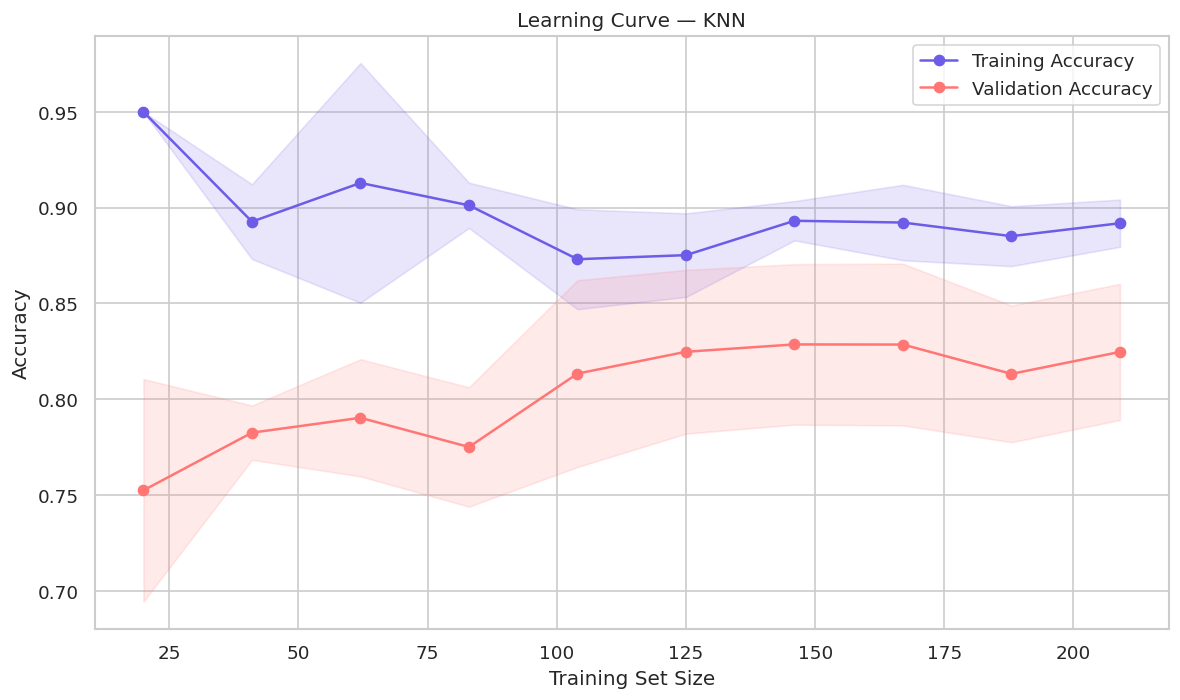

In [36]:
from sklearn.model_selection import learning_curve

train_sizes: np.ndarray
train_scores: np.ndarray
val_scores: np.ndarray

train_sizes, train_scores, val_scores = learning_curve(
    best_clf,
    X_train_resampled, y_train_resampled,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean: np.ndarray = train_scores.mean(axis=1)
val_mean: np.ndarray = val_scores.mean(axis=1)
train_std: np.ndarray = train_scores.std(axis=1)
val_std: np.ndarray = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Training Accuracy", color="#6c5ce7", marker="o")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#6c5ce7")
plt.plot(train_sizes, val_mean, label="Validation Accuracy", color="#ff7675", marker="o")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#ff7675")
plt.title(f"Learning Curve — {best_clf_name}")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Precision-Recall Curve

### Precision-Recall Curve — All Models

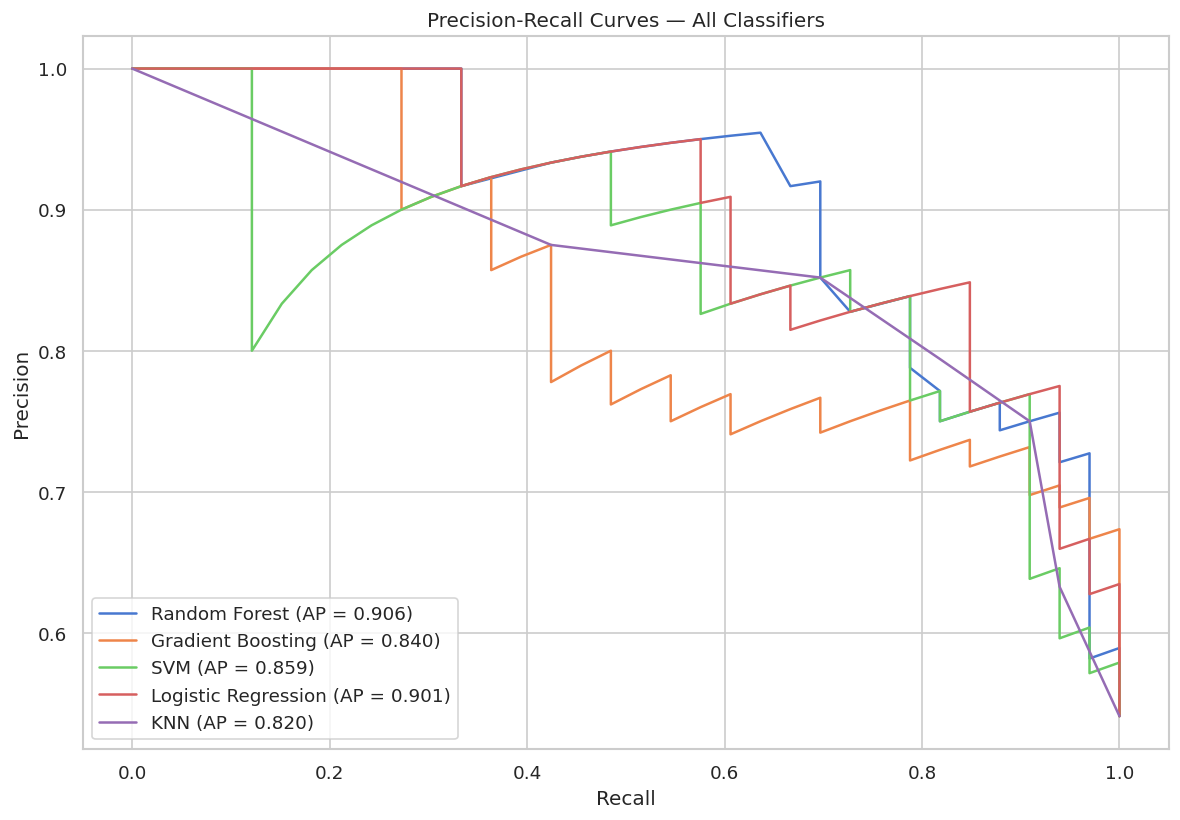

In [37]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

for name, pipeline in classifiers.items():
    y_prob: np.ndarray = pipeline.predict_proba(X_test)[:, 1]
    precision: np.ndarray
    recall: np.ndarray
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap: float = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — All Classifiers")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Threshold Analysis

### Optimal Classification Threshold — Best Model

Optimal Threshold : 0.21
Best F1 Score     : 0.8219


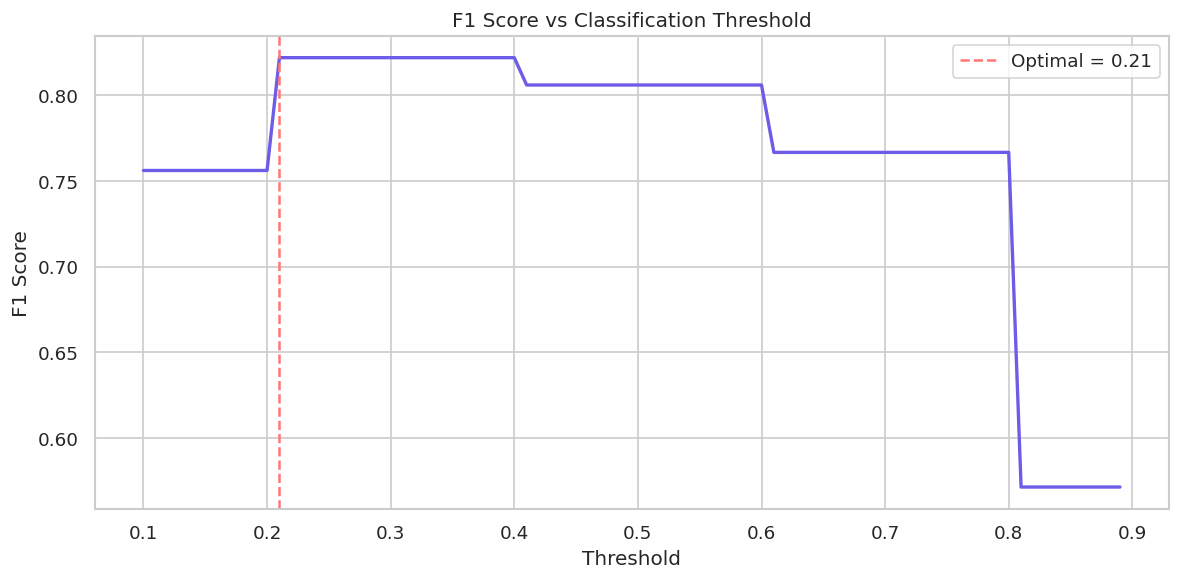

In [38]:
y_prob_best: np.ndarray = best_clf.predict_proba(X_test)[:, 1]
thresholds: np.ndarray = np.arange(0.1, 0.9, 0.01)

f1_scores: list[float] = []
from sklearn.metrics import f1_score

for threshold in thresholds:
    y_pred_thresh: np.ndarray = (y_prob_best >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))

optimal_threshold: float = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold : {optimal_threshold:.2f}")
print(f"Best F1 Score     : {max(f1_scores):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, color="#6c5ce7", linewidth=2)
plt.axvline(optimal_threshold, color="#ff7675", linestyle="--", label=f"Optimal = {optimal_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Classification Threshold")
plt.legend()
plt.tight_layout()
plt.show()

## SHAP Explainability

### SHAP Feature Importance — Best Model

PermutationExplainer explainer: 62it [00:22,  1.57it/s]


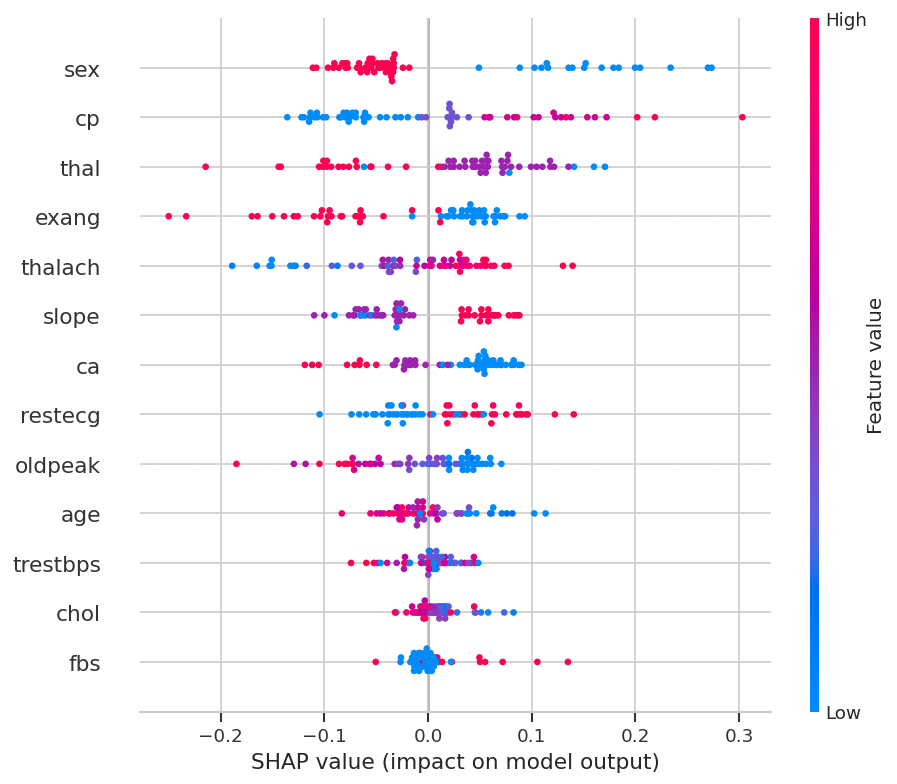

<Figure size 768x576 with 0 Axes>

<Figure size 768x576 with 0 Axes>

In [41]:
!pip install shap

import shap
import matplotlib.pyplot as plt

explainer = shap.Explainer(best_clf.predict_proba, X_train_resampled)

shap_values = explainer(X_test)

shap.summary_plot(shap_values[:, :, 1], feature_names=X.columns.tolist(), show=True)

plt.figure()

### SHAP Bar Plot

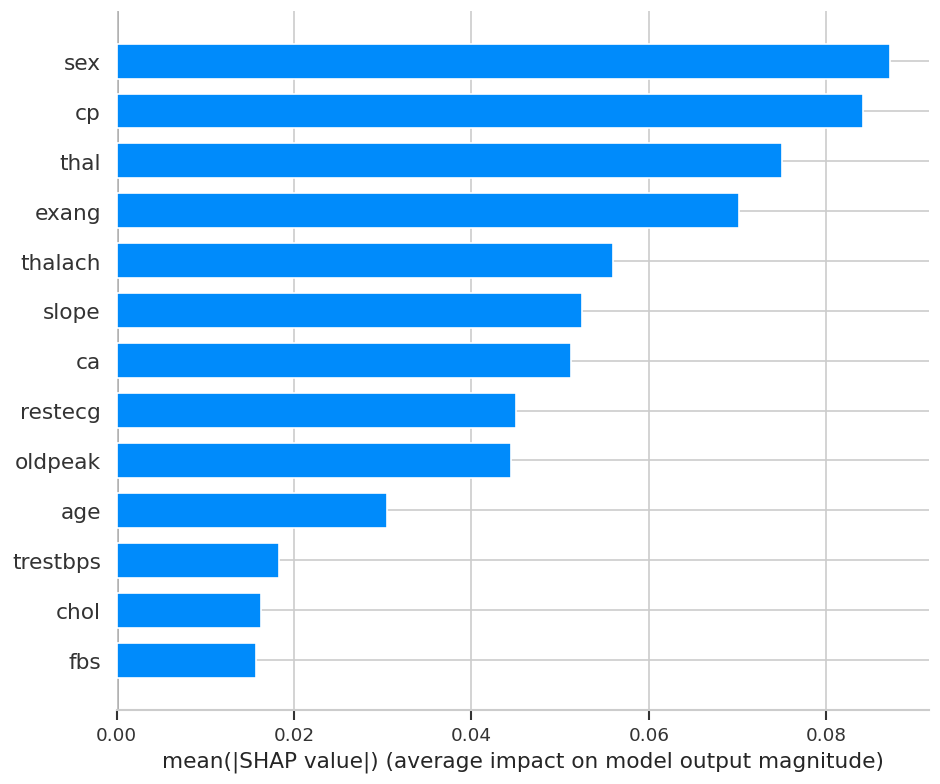

In [43]:
shap.summary_plot(shap_values[:, :, 1], feature_names=X.columns.tolist(), plot_type="bar", show=True)

## Save Final Tuned Model

In [44]:
tuned_model_path: str = "tuned_best_classifier.pkl"

with open(tuned_model_path, "wb") as f:
    pickle.dump(tuned_model, f)

print(f"Tuned model saved : '{tuned_model_path}'")
print(f"Model type        : {best_clf_name}")
print(f"Best CV Accuracy  : {grid_search.best_score_:.4f}")

Tuned model saved : 'tuned_best_classifier.pkl'
Model type        : KNN
Best CV Accuracy  : 0.8361
